# Training Analysis Notebook

This notebook analyzes the trained models on a classification task ordinary vs accidental.

## Contents

- Loading and parsing training statistics
- Training curves
- Model evaluation on test set
- Sample results

In [1]:
# Import libraries
import sys
sys.path.append('..')

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from typing import Any, Dict

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)
from collections import Counter
import csv
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import torch
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, RandomSampler, Sampler, WeightedRandomSampler
from torchvision import transforms

from typing import Any, Dict

import torch
from torch import nn
from torchvision import models

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cpu


### helpers

In [2]:
def build_model(config: Dict[str, Any], num_classes: int) -> nn.Module:
    model_config = config.get("model", {})
    name = model_config.get("architecture", model_config.get("name", "resnet50")).lower()
    pretrained = bool(model_config.get("pretrained", True))
    freeze_backbone = bool(model_config.get("freeze_backbone", True))
    hidden_units = model_config.get("head_hidden")
    dropout = float(model_config.get("dropout", 0.0))

    def build_linear_head(in_features: int, hidden_units: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, hidden_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_units, num_classes),
        )

    if name in {"resnet50", "resnet"}:
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features

        if 'head' in model_config:
            head_config = model_config['head']
            layers = head_config['layers'] + [num_classes]
            seq = []
            for i, out_features in enumerate(layers):
                seq.append(nn.Linear(in_features, out_features))
                if i < len(layers) - 1:
                    seq.append(nn.ReLU())
                in_features = out_features
            model.fc = nn.Sequential(*seq)
        elif hidden_units is not None:
            model.fc = build_linear_head(in_features, int(hidden_units))
        else:
            model.fc = nn.Linear(in_features, num_classes)
        head_parameters = [param for param in model.fc.parameters()]
    elif name in {"vit", "vit_b_16", "vision_transformer", "vision-transformer"}:
        weights = models.ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.vit_b_16(weights=weights)
        in_features = model.heads.head.in_features

        if 'head' in model_config:
            head_config = model_config['head']
            layers = head_config['layers'] + [num_classes]
            seq = []
            for i, out_features in enumerate(layers):
                seq.append(nn.Linear(in_features, out_features))
                if i < len(layers) - 1:
                    seq.append(nn.ReLU())
                in_features = out_features
            model.heads.head = nn.Sequential(*seq)
        elif hidden_units is not None:
            model.heads.head = build_linear_head(in_features, int(hidden_units))
        else:
            model.heads.head = nn.Linear(in_features, num_classes)
        head_parameters = [param for param in model.heads.head.parameters()]
    else:
        raise ValueError(f"Unsupported model name: {name}. Use resnet50 or vit_b_16.")

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in head_parameters:
            param.requires_grad = True

    return model


In [3]:
DEFAULT_SOURCE_LABEL_MAP = {
    "coco_data": "ordinary",
    "met_data": "paintings",
    "reddit_data": "accidental",
    "rijks_data": "paintings",
    "wikiart_data": "paintings",
}

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
IMAGE_NET_MEAN = [0.485, 0.456, 0.406]
IMAGE_NET_STD = [0.229, 0.224, 0.225]


class ImagePathDataset(Dataset):
    def __init__(self, records: List[Dict[str, Any]], label_to_index: Dict[str, int], transform: Optional[transforms.Compose] = None):
        self.records = records
        self.label_to_index = label_to_index
        self.transform = transform or transforms.ToTensor()

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        record = self.records[index]
        image_path = Path(record["path"])
        label = self.label_to_index[record["label"]]

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)

        return image, label


def collect_image_records(raw_root: str, source_label_map: Optional[Dict[str, str]] = None) -> List[Dict[str, str]]:
    raw_root_path = Path(raw_root)
    if not raw_root_path.exists():
        raise FileNotFoundError(f"Raw data root does not exist: {raw_root}")

    label_map = source_label_map or DEFAULT_SOURCE_LABEL_MAP
    records: List[Dict[str, str]] = []

    for source_dir in sorted(raw_root_path.iterdir()):
        if not source_dir.is_dir():
            continue

        source_name = source_dir.name
        label = label_map.get(source_name)
        if label is None:
            continue

        for image_path in sorted(source_dir.rglob("*")):
            if image_path.suffix.lower() in SUPPORTED_EXTENSIONS:
                records.append({"path": str(image_path), "label": label, "source": source_name})

    if not records:
        raise RuntimeError(f"No image records found under {raw_root}")

    return records


def filter_records_by_labels(records: List[Dict[str, str]], selected_labels: List[str]) -> List[Dict[str, str]]:
    selected = set(selected_labels)
    if not selected:
        return records
    filtered = [record for record in records if record["label"] in selected]
    if not filtered:
        raise ValueError(f"No records found for selected labels: {selected_labels}")
    return filtered


def save_split_records(records: List[Dict[str, str]], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", newline="", encoding="utf-8") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=["path", "label", "source"])
        writer.writeheader()
        writer.writerows(records)


def split_records(records: List[Dict[str, str]], train_ratio: float, val_ratio: float, test_ratio: float, seed: int) -> Tuple[List[Dict[str, str]], List[Dict[str, str]], List[Dict[str, str]]]:
    if not (0.0 < train_ratio < 1.0 and 0.0 <= val_ratio < 1.0 and 0.0 <= test_ratio < 1.0):
        raise ValueError("Invalid split ratios.")

    if abs(train_ratio + val_ratio + test_ratio - 1.0) > 1e-6:
        raise ValueError("Train/val/test split ratios must sum to 1.0.")

    labels = [record["label"] for record in records]
    if test_ratio > 0:
        train_val_records, rq1_test_records = train_test_split(
            records,
            test_size=test_ratio,
            stratify=labels,
            random_state=seed,
        )
    else:
        train_val_records, rq1_test_records = records, []

    if val_ratio > 0:
        relative_val = val_ratio / (train_ratio + val_ratio)
        train_records, val_records = train_test_split(
            train_val_records,
            test_size=relative_val,
            stratify=[record["label"] for record in train_val_records],
            random_state=seed,
        )
    else:
        train_records, val_records = train_val_records, []

    return train_records, val_records, rq1_test_records


def build_label_index(records: Iterable[Dict[str, str]]) -> Dict[str, int]:
    labels = sorted({record["label"] for record in records})
    return {label: index for index, label in enumerate(labels)}


def create_transforms(config: Dict[str, Any], is_train: bool = True) -> transforms.Compose:
    augmentation_config = config.get("augmentation", {})
    strategy = augmentation_config.get("strategy", "none").lower()
    image_size = config.get("image_size", 224)
    resize_size = augmentation_config.get("resize", image_size)

    common: List[Any] = [transforms.Resize(resize_size)]

    if is_train and strategy != "none":
        crop_size = augmentation_config.get("crop", image_size)
        horizontal_flip = augmentation_config.get("horizontal_flip", True)
        rotation = augmentation_config.get("rotation", 0)
        color_jitter = augmentation_config.get("color_jitter", {})
        auto_augment = augmentation_config.get("auto_augment", False)

        common = [transforms.RandomResizedCrop(crop_size)]
        if horizontal_flip:
            common.append(transforms.RandomHorizontalFlip())
        if rotation:
            common.append(transforms.RandomRotation(rotation))
        if color_jitter:
            brightness = color_jitter.get("brightness", 0.0)
            contrast = color_jitter.get("contrast", 0.0)
            saturation = color_jitter.get("saturation", 0.0)
            hue = color_jitter.get("hue", 0.0)
            common.append(transforms.ColorJitter(brightness=brightness, contrast=contrast, saturation=saturation, hue=hue))
        if auto_augment:
            common.append(transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET))
    else:
        common.append(transforms.CenterCrop(image_size))

    common.extend([transforms.ToTensor(), transforms.Normalize(mean=IMAGE_NET_MEAN, std=IMAGE_NET_STD)])
    return transforms.Compose(common)


def downsample_records(records: List[Dict[str, str]], seed: int) -> List[Dict[str, str]]:
    grouped: Dict[str, List[Dict[str, str]]] = {}
    for record in records:
        grouped.setdefault(record["label"], []).append(record)

    min_count = min(len(items) for items in grouped.values())
    balanced: List[Dict[str, str]] = []
    rng = torch.Generator()
    rng.manual_seed(seed)

    for label, items in grouped.items():
        if len(items) <= min_count:
            balanced.extend(items)
        else:
            indices = torch.randperm(len(items), generator=rng)[:min_count].tolist()
            balanced.extend([items[i] for i in indices])

    return balanced


def build_sampler(records: List[Dict[str, str]], label_to_index: Dict[str, int], strategy: str) -> Optional[Sampler]:
    strategy = strategy.lower()
    if strategy != "oversample":
        return None

    label_counts = Counter(record["label"] for record in records)
    if not label_counts:
        return None

    class_counts = {label_to_index[label]: count for label, count in label_counts.items()}
    max_class_count = max(class_counts.values())
    sample_weights = [1.0 / class_counts[label_to_index[record["label"]]] for record in records]
    num_samples = max_class_count * len(class_counts)
    return WeightedRandomSampler(weights=sample_weights, num_samples=num_samples, replacement=True)


def compute_class_weights(records: List[Dict[str, str]], label_to_index: Dict[str, int]) -> torch.Tensor:
    counts = Counter(record["label"] for record in records)
    num_classes = len(label_to_index)
    total = sum(counts.values())
    weights = [0.0] * num_classes

    for label, index in label_to_index.items():
        count = counts[label]
        if count > 0:
            weights[index] = float(total) / (num_classes * count)

    return torch.tensor(weights, dtype=torch.float32)


def build_dataloaders(config: Dict[str, Any]) -> Tuple[Dict[str, DataLoader], Dict[str, int], Optional[torch.Tensor]]:
    raw_root = config.get("raw_root") or config.get("dataset", {}).get("raw_root") or "data/raw"
    source_label_map = config.get("source_label_map") or config.get("dataset", {}).get("source_label_map")
    split_config = config.get("split", {})
    train_ratio = float(split_config.get("train", 0.8))
    val_ratio = float(split_config.get("val", 0.1))
    test_ratio = float(split_config.get("test", 0.1))
    seed = int(config.get("seed", 42))
    batch_size = int(config.get("training", {}).get("batch_size", 32))
    num_workers = int(config.get("training", {}).get("num_workers", 4))
    balancing = config.get("balancing", {}).get("strategy", "none").lower()

    records = collect_image_records(raw_root, source_label_map)
    selected_labels = config.get("selected_labels", [])
    if selected_labels:
        records = filter_records_by_labels(records, selected_labels)

    train_records, val_records, rq1_test_records = split_records(records, train_ratio, val_ratio, test_ratio, seed)

    if balancing == "downsample":
        train_records = downsample_records(train_records, seed)

    label_to_index = build_label_index(records)
    class_weights = None
    if balancing == "class_weight":
        class_weights = compute_class_weights(train_records, label_to_index)

    train_transform = create_transforms(config.get("augmentation", {}), is_train=True)
    eval_transform = create_transforms(config.get("augmentation", {}), is_train=False)

    train_dataset = ImagePathDataset(train_records, label_to_index, transform=train_transform)
    val_dataset = ImagePathDataset(val_records, label_to_index, transform=eval_transform) if val_records else None
    test_dataset = ImagePathDataset(rq1_test_records, label_to_index, transform=eval_transform) if rq1_test_records else None

    train_sampler = build_sampler(train_records, label_to_index, balancing)
    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=train_sampler,
        shuffle=(train_sampler is None),
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    val_loader = (
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
        if val_dataset is not None
        else None
    )
    test_loader = (
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
        if test_dataset is not None
        else None
    )

    class_names = {index: label for label, index in label_to_index.items()}
    return (
        {"train": train_loader, "val": val_loader, "test": test_loader},
        class_names,
        class_weights,
        {"train": train_records, "val": val_records, "test": rq1_test_records},
    )

In [4]:
def parse_stats_file(filepath):
    epochs = []
    train_loss = []
    train_acc = []
    train_f1 = []
    val_loss = []
    val_acc = []
    val_f1 = []

    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    rq1_train_matches = re.findall(
        r"train loss:\s*([\d.]+)\s*acc:\s*([\d.]+)\s*f1:\s*([\d.]+)",
        text
    )

    rq1_val_matches = re.findall(
        r"val\s+loss:\s*([\d.]+)\s*acc:\s*([\d.]+)\s*f1:\s*([\d.]+)",
        text
    )

    rq1_epoch_matches = re.findall(
        r"Epoch (\d+)/\d+ - [\d.]+s",
        text
    )

    if rq1_train_matches:
        epochs = [int(x) for x in rq1_epoch_matches]

        for loss, acc, f1 in rq1_train_matches:
            train_loss.append(float(loss))
            train_acc.append(float(acc))
            train_f1.append(float(f1))

        for loss, acc, f1 in rq1_val_matches:
            val_loss.append(float(loss))
            val_acc.append(float(acc))
            val_f1.append(float(f1))
    else:
        rq3_epoch_matches = re.findall(
            r"Epoch (\d+)/\d+",
            text
        )

        rq3_train_f1_matches = re.findall(
            r"Train F1:\s*([\d.]+)",
            text
        )

        rq3_val_f1_matches = re.findall(
            r"Val F1:\s*([\d.]+)",
            text
        )

        epochs = [int(x) for x in rq3_epoch_matches]
        train_f1 = [float(x) for x in rq3_train_f1_matches]
        val_f1 = [float(x) for x in rq3_val_f1_matches]

    return {
        "epochs": epochs,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    }


outputs_dir = '/content/drive/MyDrive/mgr/models'
experiments = {}
for filename in os.listdir(outputs_dir):
    if filename.endswith('_stats.txt'):
        exp_name = filename.replace('_stats.txt', '')
        filepath = os.path.join(outputs_dir, filename)
        experiments[exp_name] = parse_stats_file(filepath)

print("Loaded experiments:", list(experiments.keys()))

Loaded experiments: ['resnet_none', 'resnet_downsample', 'resnet_oversample', 'vit_class_weight', 'vit_downsample', 'vit_none', 'vit_oversample', 'rq3_resnet_keep_head', 'rq3_resnet_reset_head', 'rq3_vit_keep_head', 'rq3_vit_reset_head', 'resnet_class_weight', 'rq3_vit_reset_head_20', 'rq3_resnet_reset_head_20']


### Training performance

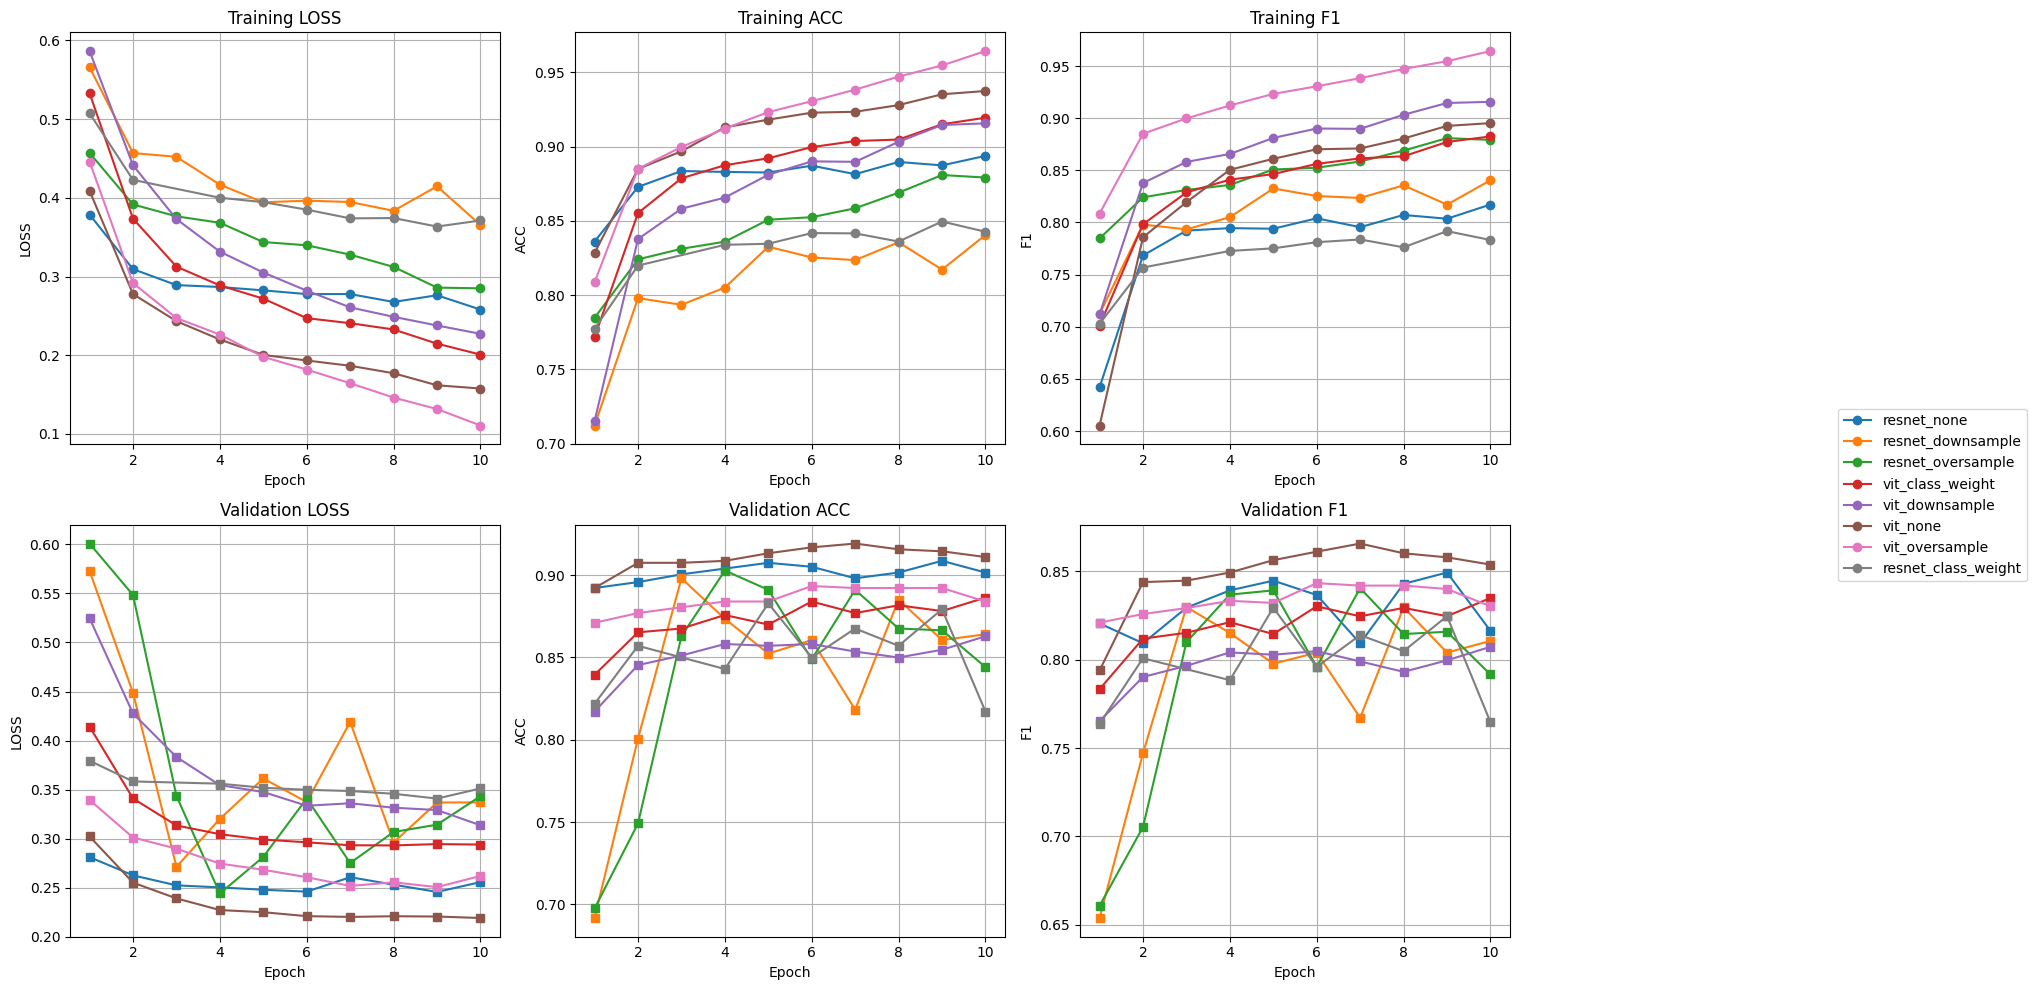

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['loss', 'acc', 'f1']

handles = []
labels = []

for i, metric in enumerate(metrics):
    ax_train = axes[0, i]
    ax_val = axes[1, i]

    for exp_name, data in experiments.items():
        if 'rq3' not in exp_name:
          epochs = data["epochs"]

          train_vals = data[f"train_{metric}"]
          val_vals = data[f"val_{metric}"]

          if len(train_vals) == 0 or len(val_vals) == 0:
              continue

          min_len = min(len(epochs), len(train_vals), len(val_vals))
          epochs_plot = epochs[:min_len]

          train_line, = ax_train.plot(
              epochs_plot,
              train_vals[:min_len],
              label=exp_name,
              marker="o"
          )

          ax_val.plot(
              epochs_plot,
              val_vals[:min_len],
              label=exp_name,
              marker="s"
          )

          if i == 0:
              handles.append(train_line)
              labels.append(exp_name)

    ax_train.set_title(f"Training {metric.upper()}")
    ax_train.set_xlabel("Epoch")
    ax_train.set_ylabel(metric.upper())
    ax_train.grid(True)

    ax_val.set_title(f"Validation {metric.upper()}")
    ax_val.set_xlabel("Epoch")
    ax_val.set_ylabel(metric.upper())
    ax_val.grid(True)

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

The data shows that Vision Transformers (ViT) generally outperform ResNet across all metrics. Models trained with oversampling tend to achieve the highest performance scores, while models using downsampling are consistently the most unstable and least effective. The ViT models show a much higher capacity to learn the training data (reaching near-perfect scores) but exhibit a notable gap between training and validation performance, indicating some degree of overfitting.

#### ResNet Performance

* **Best Variant: resnet_none (Standard)**
While `resnet_oversample` reaches slightly higher peak F1 scores at certain points, the standard `resnet_none` model is the most stable. it maintains a consistent upward trend in accuracy and F1 score with the least amount of "jitter" in the validation loss.
* **Worst Variant: resnet_downsample**
This is clearly the worst-performing ResNet model. Its validation metrics are extremely volatile, with sharp drops in accuracy and huge spikes in loss. This suggests that removing data to balance the classes deprived the model of the features it needed to generalize properly.

#### ViT (Vision Transformer) Performance

* **Best Variant: vit_oversample**
This model achieved the highest overall training and validation F1 scores. By replicating minority class samples, the Transformer was able to learn the nuances of the dataset more effectively than any other configuration. (Note: `vit_none` is a close runner-up as it achieved the lowest overall validation loss).
* **Worst Variant: vit_downsample**
Similar to the ResNet architecture, the downsampling strategy performed the poorest for ViT. It resulted in the lowest validation accuracy and F1 scores among the Transformer group, confirming that reducing the dataset size is detrimental to these high-capacity models.


#### Summary

The most reliable and high-performing model is **vit_oversample**. A more lightweight or stable alternative is **resnet_none** among the traditional architectures. **Downsampling** in both cases significantly degrades performance and stability.

### Test data

In [6]:
from pathlib import PureWindowsPath
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def build_test_records(test_csv_path):

    IMAGE_DIR = "/content/drive/MyDrive/mgr/colab_test_images"

    test_df = pd.read_csv(test_csv_path)

    unique_labels = sorted(
        test_df["label"].unique()
    )

    label_to_index = {
        label: idx
        for idx, label in enumerate(unique_labels)
    }

    index_to_label = {
        v: k
        for k, v in label_to_index.items()
    }

    records = []

    for _, row in test_df.iterrows():

        original_path = row["path"]

        filename = PureWindowsPath(
            original_path
        ).name

        path = os.path.join(
            IMAGE_DIR,
            filename
        )

        records.append({
            "path": path,
            "label": row["label"]
        })

    return records, label_to_index, index_to_label


rq1_test_records, rq1_label_to_index, rq1_index_to_label = build_test_records(
    "/content/drive/MyDrive/mgr/splits/rq1_test_records.csv"
)

rq1_test_dataset = ImagePathDataset(
    rq1_test_records,
    rq1_label_to_index,
    transform=transform
)

rq1_test_loader = DataLoader(
    rq1_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("RQ1 labels:", rq1_label_to_index)
print("RQ1 size:", len(rq1_test_dataset))


rq3_test_records, rq3_label_to_index, rq3_index_to_label = build_test_records(
    "/content/drive/MyDrive/mgr/splits/rq3_test_records.csv"
)

rq3_test_dataset = ImagePathDataset(
    rq3_test_records,
    rq3_label_to_index,
    transform=transform
)

rq3_test_loader = DataLoader(
    rq3_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("RQ3 labels:", rq3_label_to_index)
print("RQ3 size:", len(rq3_test_dataset))

RQ1 labels: {'accidental': 0, 'ordinary': 1}
RQ1 size: 853
RQ3 labels: {'normal': 0, 'paintings': 1}
RQ3 size: 1374


### Evaluation and Confusion Matrix

In [ ]:
def load_model_for_evaluation(model_path, device):
    checkpoint = torch.load(
        model_path,
        map_location=device
    )

    print(f"\nLoading: {os.path.basename(model_path)}")

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    config = checkpoint.get("config", None)

    if config is not None:
        print("Using saved config:")
        print(config["model"])

        classifier_keys = [
            k for k in state_dict.keys()
            if (
                ("fc" in k or "heads.head" in k)
                and "weight" in k
            )
        ]

        final_key = sorted(classifier_keys)[-1]
        num_classes = state_dict[final_key].shape[0]

        model = build_model(
            config=config,
            num_classes=num_classes
        ).to(device)

    else:
        print("No config found → inferring architecture")

        if any(k.startswith("heads.head") for k in state_dict.keys()):
            architecture = "vit_b_16"
            print("Detected ViT")

            vit_weight_keys = sorted([
                k for k in state_dict.keys()
                if k.startswith("heads.head") and "weight" in k
            ])

            print("ViT head keys:", vit_weight_keys)

            if len(vit_weight_keys) == 1:
                final_key = vit_weight_keys[0]

                num_classes = state_dict[
                    final_key
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True
                    }
                }

            elif len(vit_weight_keys) >= 2:
                first_key = vit_weight_keys[0]
                final_key = vit_weight_keys[-1]

                hidden_units = state_dict[
                    first_key
                ].shape[0]

                num_classes = state_dict[
                    final_key
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            else:
                raise ValueError(
                    f"Unknown ViT structure: {vit_weight_keys}"
                )

        else:
            architecture = "resnet50"
            print("Detected ResNet")
            if "fc.1.weight" in state_dict:
                hidden_units = state_dict[
                    "fc.1.weight"
                ].shape[0]

                num_classes = state_dict[
                    "fc.4.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            elif "fc.0.weight" in state_dict:
                hidden_units = state_dict[
                    "fc.0.weight"
                ].shape[0]

                num_classes = state_dict[
                    "fc.3.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            else:
                num_classes = state_dict[
                    "fc.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True
                    }
                }

        print("Reconstructed config:")
        print(config)

        model = build_model(
            config=config,
            num_classes=num_classes
        ).to(device)

    missing, unexpected = model.load_state_dict(
        state_dict,
        strict=False
    )

    if missing:
        print("Missing keys:", missing)

    if unexpected:
        print("Unexpected keys:", unexpected)

    model.eval()
    return model

def evaluate_model(model, test_loader, device):

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            probs = F.softmax(
                outputs,
                dim=1
            )

            preds = outputs.argmax(dim=1)

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    acc = accuracy_score(
        all_targets,
        all_preds
    )

    f1 = f1_score(
        all_targets,
        all_preds,
        average="weighted"
    )

    precision = precision_score(
        all_targets,
        all_preds,
        average="weighted"
    )

    recall = recall_score(
        all_targets,
        all_preds,
        average="weighted"
    )

    cm = confusion_matrix(
        all_targets,
        all_preds
    )

    # ROC only for binary
    if len(set(all_targets)) == 2:
        probs_positive = [
            p[1] for p in all_probs
        ]

        roc_auc = roc_auc_score(
            all_targets,
            probs_positive
        )
    else:
        roc_auc = None

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
        "confusion_matrix": cm
    }


test_results = {}

for exp_name in experiments.keys():

    model_path = os.path.join(
        outputs_dir,
        f"{exp_name}.pt"
    )

    if not os.path.exists(model_path):
        print(f"Missing model: {model_path}")
        continue

    print(f"\nEvaluating {exp_name}")

    if "rq3" in exp_name.lower():
        current_test_loader = rq3_test_loader

        labels = sorted(
            list(set(
                x["label"]
                for x in rq3_test_records
            ))
        )

    else:
        current_test_loader = rq1_test_loader

        labels = sorted(
            list(set(
                x["label"]
                for x in rq1_test_records
            ))
        )

    current_index_to_label = {
        idx: label
        for idx, label in enumerate(labels)
    }

    model = load_model_for_evaluation(
        model_path,
        device
    )

    metrics = evaluate_model(
        model,
        current_test_loader,
        device
    )

    metrics["index_to_label"] = current_index_to_label

    test_results[exp_name] = metrics


print("\nFinished evaluation")
print(test_results.keys())

final_metrics = {}

for exp_name, data in experiments.items():

    final_metrics[exp_name] = {
        "val_loss": data["val_loss"][-1] if len(data["val_loss"]) else None,
        "val_acc": data["val_acc"][-1] if len(data["val_acc"]) else None,
        "val_f1": data["val_f1"][-1] if len(data["val_f1"]) else None,

        "test_acc": test_results.get(exp_name, {}).get("accuracy"),
        "test_f1": test_results.get(exp_name, {}).get("f1"),
        "test_precision": test_results.get(exp_name, {}).get("precision"),
        "test_recall": test_results.get(exp_name, {}).get("recall"),
        "test_roc_auc": test_results.get(exp_name, {}).get("roc_auc"),
    }

comparison_df = pd.DataFrame.from_dict(
    final_metrics,
    orient="index"
)

print("\nFinal Comparison:")
display(comparison_df)


Evaluating resnet_none

Loading: resnet_none.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 96.8MB/s]


In [ ]:
def plot_confusion_matrix(cm, exp_name, labels):
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 14},
        cbar=False
    )

    plt.title(f"Confusion Matrix - {exp_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


print("\nConfusion Matrices:")

for exp_name, metrics in test_results.items():

    labels = [
        metrics["index_to_label"][i]
        for i in sorted(metrics["index_to_label"].keys())
    ]

    plot_confusion_matrix(
        metrics["confusion_matrix"],
        exp_name,
        labels
    )

### Sample images analysis

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import torch
from torchvision import transforms

sample_indices = [0, 1, 2, 3, 4]

model_preds = {}
sample_metadata = {}

for exp_name in experiments.keys():
    model_path = os.path.join(
        outputs_dir,
        f"{exp_name}.pt"
    )

    if not os.path.exists(model_path):
        print(f"Missing model: {exp_name}")
        continue

    print(f"\nRunning predictions for {exp_name}")

    if "rq3" in exp_name.lower():
        current_loader = rq3_test_loader
        current_records = rq3_test_records
    else:
        current_loader = rq1_test_loader
        current_records = rq1_test_records

    dataset = current_loader.dataset

    sample_tensors = []

    for idx in sample_indices:
        img_tensor, _ = dataset[idx]
        sample_tensors.append(img_tensor)

    sample_images = torch.stack(
        sample_tensors
    ).to(device)

    sample_metadata[exp_name] = {
        "records": current_records,
        "images": sample_images
    }

    try:
        model = load_model_for_evaluation(
            model_path,
            device
        )

        with torch.no_grad():
            outputs = model(sample_images)

            preds = outputs.argmax(
                dim=1
            ).cpu().tolist()

        model_preds[exp_name] = preds

    except Exception as e:
        print(f"Failed on {exp_name}: {e}")


rq1_rows = []
rq3_rows = []

for exp_name, preds in model_preds.items():

    records = sample_metadata[
        exp_name
    ]["records"]

    label_map = test_results[
        exp_name
    ]["index_to_label"]

    target_rows = (
        rq3_rows
        if "rq3" in exp_name.lower()
        else rq1_rows
    )

    for pos, idx in enumerate(sample_indices):
        existing = next(
            (
                r for r in target_rows
                if r["index"] == idx
            ),
            None
        )

        if existing is None:
            existing = {
                "index": idx,
                "path": records[idx]["path"],
                "true_label": records[idx]["label"]
            }
            target_rows.append(existing)

        existing[exp_name] = label_map.get(
            preds[pos],
            f"class_{preds[pos]}"
        )


rq1_sample_df = pd.DataFrame(rq1_rows)
rq3_sample_df = pd.DataFrame(rq3_rows)

print("\nRQ1 sample predictions:")
display(rq1_sample_df)

print("\nRQ3 sample predictions:")
display(rq3_sample_df)


inv_norm = transforms.Normalize(
    mean=[
        -m / s
        for m, s in zip(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ],
    std=[
        1 / s
        for s in [0.229, 0.224, 0.225]
    ]
)

for dataset_name in ["rq1", "rq3"]:
    relevant_models = [
        exp for exp in model_preds
        if dataset_name in exp.lower()
    ]

    if not relevant_models:
        continue

    records = (
        rq3_test_records
        if dataset_name == "rq3"
        else rq1_test_records
    )

    loader = (
        rq3_test_loader
        if dataset_name == "rq3"
        else rq1_test_loader
    )

    dataset = loader.dataset

    sample_tensors = []

    for idx in sample_indices:
        if idx >= len(dataset):
            print(
                f"Skipping idx {idx} for {dataset_name}: "
                f"dataset only has {len(dataset)} samples"
            )
            continue

        img_tensor, _ = dataset[idx]
        sample_tensors.append(img_tensor)

    sample_images = torch.stack(sample_tensors)

    fig, axes = plt.subplots(
        len(sample_indices),
        1,
        figsize=(10, 4 * len(sample_indices))
    )

    if len(sample_indices) == 1:
        axes = [axes]

    for pos, idx in enumerate(sample_indices):
        img = inv_norm(
            sample_images[pos]
        ).clamp(0, 1)

        img = img.permute(
            1, 2, 0
        ).numpy()

        ax = axes[pos]
        ax.imshow(img)
        ax.axis("off")

        pred_lines = "\n".join(
            f"{exp}: {test_results[exp]['index_to_label'][model_preds[exp][pos]]}"
            for exp in relevant_models
        )

        ax.set_title(
            f"{dataset_name.upper()} idx={idx} | true={records[idx]['label']}\n{pred_lines}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()